# 04 · Where Greedy Fails (the showpiece)

XOR: two features whose **combination** is the label, but neither feature alone carries any information. The greedy first-split search therefore finds ~zero gain and is stumped — while on a checkerboard, axis-aligned greedy splits are exactly right. This is why a single tree is not enough, and why forests exist.

**Artifacts:** `outputs/figures/04_*.png`, `outputs/data/04_*.json`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from src.config import load_settings
from src.datasets import xor, checkerboard, moons
from src.tree.criteria import information_gain
from src.tree.splitter import best_split
from src.tree.classifier import DecisionTreeClassifier
from src.evaluation import accuracy, plot_decision_boundary, train_test_accuracy_vs_depth
from src.outputs import save_figure, save_json

SEED = load_settings().seed
RES = 200
Xm, ym = moons(n_samples=400, noise=0.2, seed=SEED)     # easy baseline
Xx, yx = xor(n_samples=400, noise=0.05, seed=SEED)
Xc, yc = checkerboard(n_samples=400, grid=2, seed=SEED)

## Three problems. To a human, the last two look as easy as the first.

PosixPath('/workspaces/decision_trees_101/outputs/figures/04_data.png')

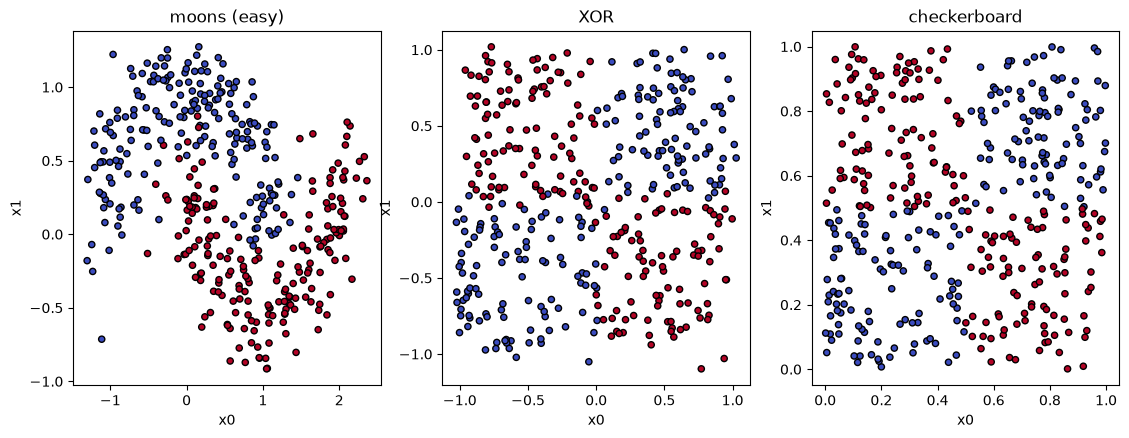

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
trio = [(Xm, ym, 'moons (easy)'), (Xx, yx, 'XOR'), (Xc, yc, 'checkerboard')]
for ax, (X, y, name) in zip(axes, trio, strict=True):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=20)
    ax.set(title=name, xlabel='x0', ylabel='x1')
save_figure(fig, '04_data')

## The greedy first split: gain at the root
The best gain available on *each single feature*, and the overall root gain the splitter finds. The easy problem hands greedy a strong first cut; XOR and the checkerboard give it almost nothing, because the label needs two features at once and greedy only ever looks at one.

In [3]:
def root_gains(X, y):
    per_feature = []
    for f in range(X.shape[1]):
        xs = np.unique(X[:, f])
        th = (xs[:-1] + xs[1:]) / 2
        per_feature.append(float(max(information_gain(y, X[:, f] <= t, 'gini') for t in th)))
    split = best_split(X, y, criterion='gini')
    return {'per_feature_best_gain': per_feature, 'root_gain': float(split.gain)}

gains = {'moons': root_gains(Xm, ym), 'XOR': root_gains(Xx, yx), 'checkerboard': root_gains(Xc, yc)}
for name, g in gains.items():
    print(f"{name:13s} per-feature {np.round(g['per_feature_best_gain'], 4).tolist()}  root {g['root_gain']:.4f}")
save_json(gains, '04_root_gains')

moons         per-feature [0.1285, 0.2142]  root 0.2142
XOR           per-feature [0.0221, 0.0075]  root 0.0221
checkerboard  per-feature [0.0134, 0.0069]  root 0.0134


PosixPath('/workspaces/decision_trees_101/outputs/data/04_root_gains.json')

PosixPath('/workspaces/decision_trees_101/outputs/figures/04_root_gain_comparison.png')

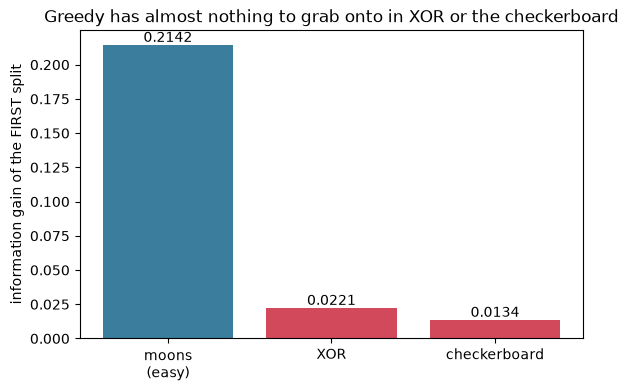

In [4]:
keys = ['moons', 'XOR', 'checkerboard']
labels = ['moons\n(easy)', 'XOR', 'checkerboard']
root = [gains[k]['root_gain'] for k in keys]
fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(labels, root, color=['#3a7d9c', '#d1495b', '#d1495b'])
ax.bar_label(bars, fmt='%.4f')
ax.set(ylabel='information gain of the FIRST split',
       title='Greedy has almost nothing to grab onto in XOR or the checkerboard')
save_figure(fig, '04_root_gain_comparison')

## What happens *after* the blind first split
Given depth, the tree solves both. On the checkerboard the true boundaries are axis-aligned, so the staircase fits it perfectly — the tree's strength. XOR is the minimal instance of the same first-split blindness, solved only by a convoluted route.

PosixPath('/workspaces/decision_trees_101/outputs/figures/04_boundaries.png')

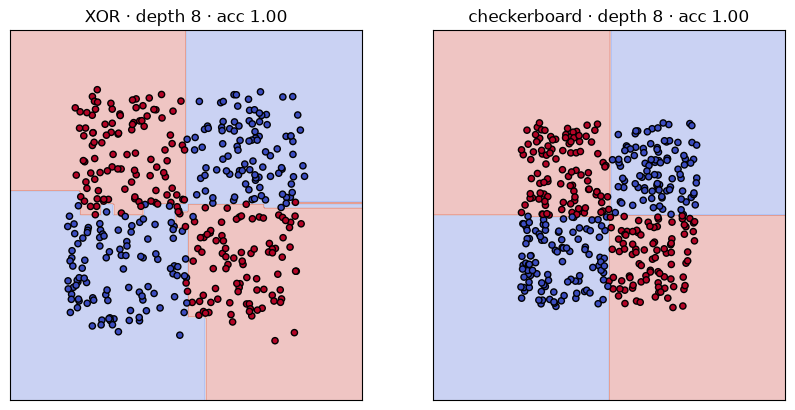

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
for ax, (X, y, name) in zip(axes, [(Xx, yx, 'XOR'), (Xc, yc, 'checkerboard')], strict=True):
    clf = DecisionTreeClassifier(max_depth=8).fit(X, y)
    plot_decision_boundary(clf, X, y, ax=ax, resolution=RES,
                           title=f'{name} · depth 8 · acc {accuracy(y, clf.predict(X)):.2f}')
save_figure(fig, '04_boundaries')

## Accuracy vs depth on XOR
A depth-1 stump is no better than a coin flip; the tree only recovers once depth ≥ 2 lets it combine the two features.

PosixPath('/workspaces/decision_trees_101/outputs/data/04_xor_depth_accuracy.json')

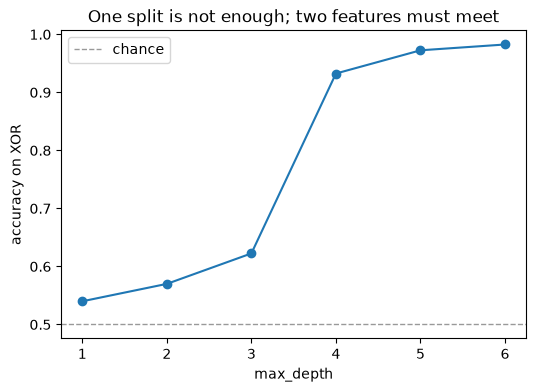

In [6]:
rows = train_test_accuracy_vs_depth(Xx, yx, Xx, yx, depths=range(1, 7))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([r['depth'] for r in rows], [r['train'] for r in rows], marker='o')
ax.axhline(0.5, color='0.6', ls='--', lw=1, label='chance')
ax.set(xlabel='max_depth', ylabel='accuracy on XOR', title='One split is not enough; two features must meet')
ax.legend()
save_figure(fig, '04_xor_depth_accuracy')
save_json({'seed': SEED, 'xor_accuracy_vs_depth': rows,
           'depth1_gain': gains['XOR']['root_gain']}, '04_xor_depth_accuracy')

## Takeaway
Greediness is fast and flexible but **blind to feature interactions at the first split**. XOR is the clean proof: the root gain is essentially zero. That blindness is exactly what an ensemble of trees is built to repair — notebook 06.